# Library

In [ ]:
!pip install gensim stanza sklearn_crfsuite

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from sklearn_crfsuite import CRF
from sklearn_crfsuite.metrics import flat_classification_report, flat_f1_score
from sklearn_crfsuite.metrics import flatten
from gensim.models import FastText
import warnings
import numpy as np
import seaborn as sns
from collections import Counter
import gensim
import pickle
import os
import re
import unicodedata
import nltk
import stanza
stanza.download('id')
warnings.filterwarnings('ignore')

INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/stanza_resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources


# EDA

Load Data

In [ ]:
def read_conll(file_path):
    sentences = []
    sentence = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if sentence:
                    sentences.append(sentence)
                    sentence = []
            else:
                parts = line.split()
                if len(parts) == 3:
                    token, pos, ner = parts
                    sentence.append((token, pos, ner))
    if sentence:
        sentences.append(sentence)
    return sentences

In [ ]:
train_sentences = read_conll(f'train.txt')
dev_sentences   = read_conll(f'dev.txt')
test_sentences  = read_conll(f'test.txt')

print(f"✅ Data Loaded: {len(train_sentences)} train, {len(dev_sentences)} dev, {len(test_sentences)} test")

def conll_to_df(sentences):
    data = []
    for sent in sentences:
        for token, pos, ner in sent:
            data.append({'Token': token, 'PoS': pos, 'NER': ner})
    return pd.DataFrame(data)

train_df = conll_to_df(train_sentences)
dev_df   = conll_to_df(dev_sentences)
test_df  = conll_to_df(test_sentences)

print("\n📄 Contoh Train Data:")
display(train_df.head(10))

✅ Data Loaded: 1464 train, 367 dev, 509 test

📄 Contoh Train Data:


,Token,PoS,NER
0,Berikut,PROPN,O
1,adalah,AUX,O
2,tujuh,NUM,O
3,kota,NOUN,O
4,di,ADP,O
5,Indonesia,PROPN,B-LOC
6,yang,PRON,O
7,dianggap,VERB,O
8,paling,ADV,O
9,nyaman,ADJ,O


Ukuran Dataset

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30248 entries, 0 to 30247
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Token   30248 non-null  object
 1   PoS     30248 non-null  object
 2   NER     30248 non-null  object
dtypes: object(3)
memory usage: 709.1+ KB


In [ ]:
dev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7863 entries, 0 to 7862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Token   7863 non-null   object
 1   PoS     7863 non-null   object
 2   NER     7863 non-null   object
dtypes: object(3)
memory usage: 184.4+ KB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10588 entries, 0 to 10587
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Token   10588 non-null  object
 1   PoS     10588 non-null  object
 2   NER     10588 non-null  object
dtypes: object(3)
memory usage: 248.3+ KB


In [ ]:
print("\nDataset sizes:")
print(f"Train: {len(train_df)} tokens")
print(f"Dev:   {len(dev_df)} tokens")
print(f"Test:  {len(test_df)} tokens")

total_tokens = len(train_df) + len(dev_df) + len(test_df)
print(f"\nTotal token di seluruh dataset: {total_tokens}")


Dataset sizes:
Train: 30248 tokens
Dev:   7863 tokens
Test:  10588 tokens

Total token di seluruh dataset: 48699


In [ ]:
print(f"\nNumber of sentences:")
print(f"Train: {len(train_sentences)}")
print(f"Dev:   {len(dev_sentences)}")
print(f"Test:  {len(test_sentences)}")

total_sentences = len(train_sentences) + len(dev_sentences) + len(test_sentences)
print(f"\nTotal kalimat di seluruh dataset: {total_sentences}")


Number of sentences:
Train: 1464
Dev:   367
Test:  509

Total kalimat di seluruh dataset: 2340


Distribusi POS

|  Tag PoS  | Keterangan                                                                   |
| :-------: | :--------------------------------------------------------------------------- |
| **PROPN** | Proper noun / Kata benda khusus (nama orang, tempat, organisasi).            |
|  **AUX**  | Auxiliary verb / Kata bantu (*akan*, *telah*, *sedang*).                     |
|  **NUM**  | Number / Angka atau bilangan.                                                |
|  **NOUN** | Noun / Kata benda umum (*orang*, *buku*, *konsep*).                          |
|  **ADP**  | Adposition / Preposisi (*di*, *ke*, *dari*, *pada*).                         |
|  **PRON** | Pronoun / Kata ganti (*saya*, *kamu*, *dia*, *mereka*).                      |
|  **VERB** | Verb / Kata kerja (*makan*, *berjalan*, *berbicara*).                        |
|  **ADV**  | Adverb / Kata keterangan (*sangat*, *cepat*, *tidak*).                       |
|  **ADJ**  | Adjective / Kata sifat (*besar*, *bagus*, *indah*).                          |
| **PUNCT** | Punctuation / Tanda baca.                                                    |
|  **DET**  | Determiner / Penentu (*ini*, *itu*, *seorang*).                              |
|  **PART** | Particle / Partikel (*pun*, *lah*, *kah*).                                   |
| **SCONJ** | Subordinating conjunction / Kata sambung bawahan (*karena*, *agar*, *jika*). |
| **CCONJ** | Coordinating conjunction / Kata sambung setara (*dan*, *atau*, *tetapi*).    |
|  **SYM**  | Symbol / Simbol (*%*, *$*, *#*, dll).                                        |
|   **X**   | Other / Lainnya (tidak terklasifikasi).                                      |


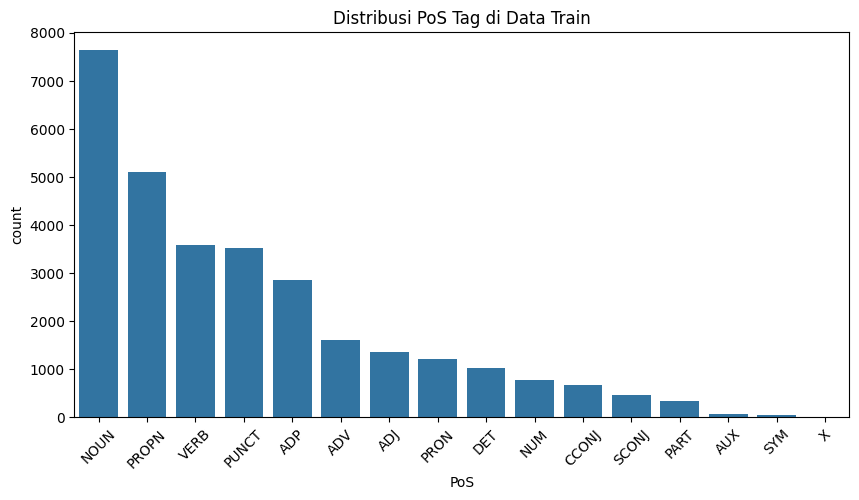

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='PoS', data=train_df, order=train_df['PoS'].value_counts().index)
plt.title("Distribusi PoS Tag di Data Train")
plt.xticks(rotation=45)
plt.show()

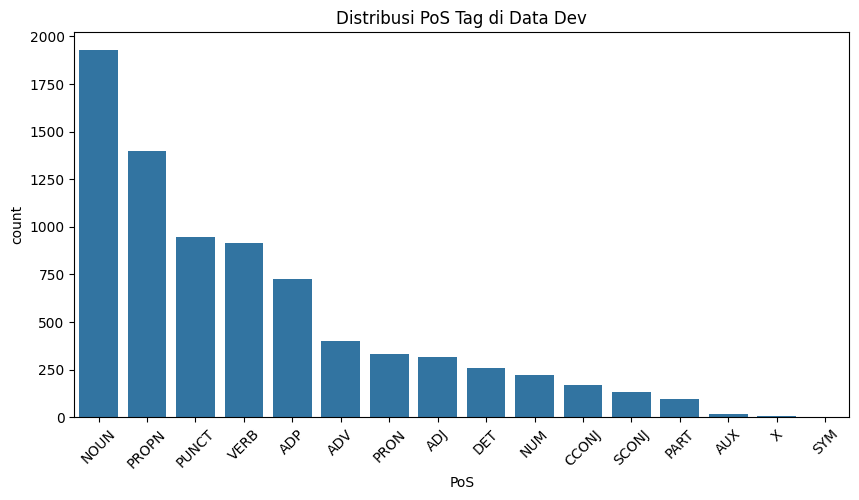

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='PoS', data=dev_df, order=dev_df['PoS'].value_counts().index)
plt.title("Distribusi PoS Tag di Data Dev")
plt.xticks(rotation=45)
plt.show()

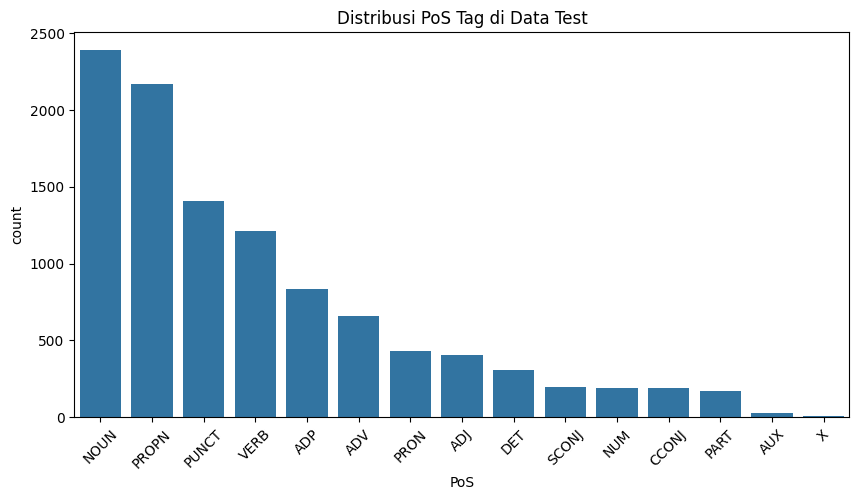

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='PoS', data=test_df, order=test_df['PoS'].value_counts().index)
plt.title("Distribusi PoS Tag di Data Test")
plt.xticks(rotation=45)
plt.show()

Distribusi NER

|  Tag NER  | Keterangan                                                              |
| :-------: | :---------------------------------------------------------------------- |
| **B-LOC** | Awal (Begin) dari nama lokasi, misalnya *Jakarta*, *Indonesia*, *Bali*. |
| **I-LOC** | Di dalam (Inside) nama lokasi yang sama.                                |
| **B-ORG** | Awal dari nama organisasi, misalnya *UN*, *PPP*, *Universitas Udayana*. |
| **I-ORG** | Di dalam nama organisasi yang sama.                                     |
| **B-PER** | Awal dari nama orang, misalnya *Joko Widodo*, *Haposan*.                |
| **I-PER** | Di dalam nama orang yang sama.                                          |
|   **O**   | Token di luar entitas (Other).                                          |


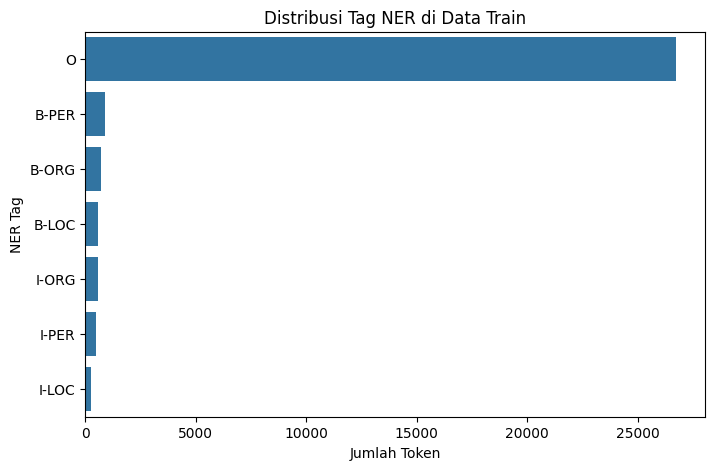

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='NER', data=train_df, order=train_df['NER'].value_counts().index)
plt.title("Distribusi Tag NER di Data Train")
plt.xlabel("Jumlah Token")
plt.ylabel("NER Tag")
plt.show()

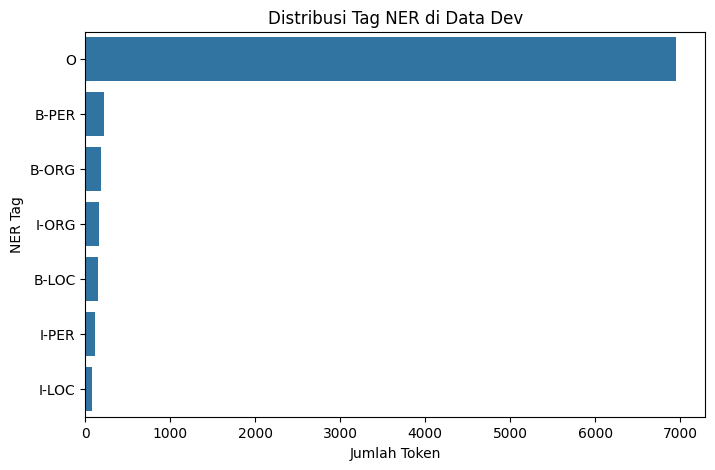

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='NER', data=dev_df, order=dev_df['NER'].value_counts().index)
plt.title("Distribusi Tag NER di Data Dev")
plt.xlabel("Jumlah Token")
plt.ylabel("NER Tag")
plt.show()

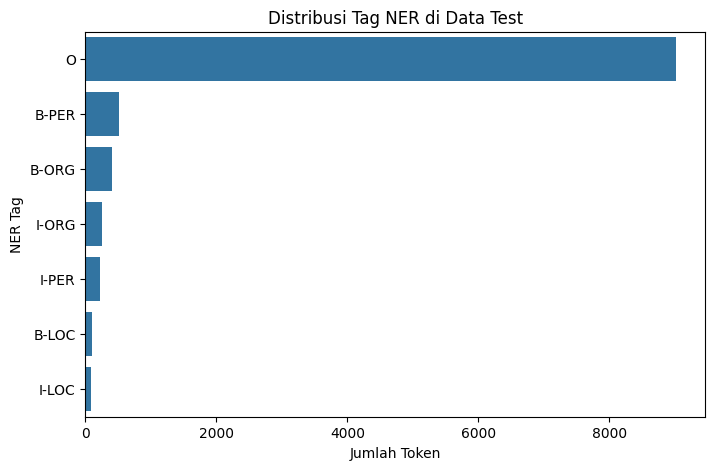

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='NER', data=test_df, order=test_df['NER'].value_counts().index)
plt.title("Distribusi Tag NER di Data Test")
plt.xlabel("Jumlah Token")
plt.ylabel("NER Tag")
plt.show()

|  Tag  | Arti        | Keterangan                                                                                                                                        |
| :---: | :---------- | :------------------------------------------------------------------------------------------------------------------------------------------------ |
| **B** | **Begin**   | Menandai **awal** dari sebuah entitas. Misalnya: `B-PER` berarti awal dari nama orang, `B-ORG` awal dari nama organisasi.                         |
| **I** | **Inside**  | Menandai token yang **masih berada di dalam** entitas yang sama dengan tag sebelumnya. Misalnya: `I-PER` berarti bagian lanjutan dari nama orang. |
| **O** | **Outside** | Menandai token yang **tidak termasuk** dalam entitas apa pun (bukan nama orang, organisasi, atau lokasi).                                         |


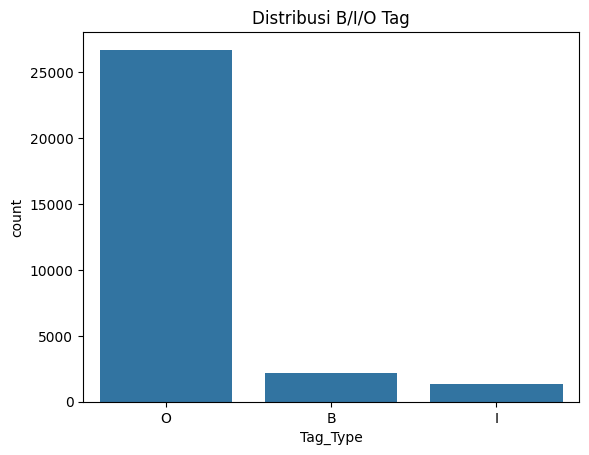

In [ ]:
train_df['Tag_Type'] = train_df['NER'].apply(lambda x: x.split('-')[0] if '-' in x else x)
sns.countplot(x='Tag_Type', data=train_df)
plt.title("Distribusi B/I/O Tag")
plt.show()

Contoh Data

In [ ]:
for sent in train_sentences[:3]:
    print(" ".join([t[0] for t in sent]))
    print(" ".join([t[2] for t in sent]))
    print()

Berikut adalah tujuh kota di Indonesia yang dianggap paling nyaman untuk ditinggali :
O O O O O B-LOC O O O O O O O

Soal calon presiden itu urusan nanti , yang penting menang dulu lah , kata Anis di Samarinda , Kalimantan Timur , Selasa (29/10/2013) .
O O O O O O O O O O O O O O B-PER O B-LOC O B-LOC I-LOC O O O O

Kalau itu tanya PPP saja , ujar Nasir sambil memasuki ruang rapat konsultasi pimpinan fraksi dan kelompok DPD .
O O O B-ORG O O O B-PER O O O O O O O O O O O



# Preprocessing

In [ ]:
nlp = stanza.Pipeline(lang='id', processors='tokenize,pos')

def preprocess_text(text):
    text = unicodedata.normalize("NFKC", text).strip()
    doc = nlp(text)

    tokens = []
    pos_tags = []

    for sent in doc.sentences:
        for word in sent.words:
            tokens.append(word.text)
            pos_tags.append(word.upos)

    return tokens, pos_tags

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


In [ ]:
text1 = "Presiden Prabowo Subianto bertemu dengan Bahlil di Istana Negara."
text2 = "Ｐｒｅｓｉｄｅｎ Ｊｏｋｏｗｉ　ｍｅｎｇｕｍｕｍｋａｎ　ｋｅｂｉｊａｋａｎ　baru."
text3 = "Harga naik sebesar １５％ dalam ３ bulan."

tokens1, pos1 = preprocess_text(text1)
tokens2, pos2 = preprocess_text(text2)
tokens3, pos3 = preprocess_text(text3)

print("=== TEXT 1 ===")
print("TOKENS:", tokens1)
print("POS TAGS:", pos1)

print("\n=== TEXT 2 ===")
print("TOKENS:", tokens2)
print("POS TAGS:", pos2)

print("\n=== TEXT 3 ===")
print("TOKENS:", tokens3)
print("POS TAGS:", pos3)

=== TEXT 1 ===
TOKENS: ['Presiden', 'Prabowo', 'Subianto', 'bertemu', 'dengan', 'Bahlil', 'di', 'Istana', 'Negara', '.']
POS TAGS: ['PROPN', 'PROPN', 'PROPN', 'VERB', 'ADP', 'PROPN', 'ADP', 'PROPN', 'PROPN', 'PUNCT']

=== TEXT 2 ===
TOKENS: ['Presiden', 'Jokowi', 'mengumumkan', 'kebijakan', 'baru', '.']
POS TAGS: ['PROPN', 'PROPN', 'VERB', 'NOUN', 'ADJ', 'PUNCT']

=== TEXT 3 ===
TOKENS: ['Harga', 'naik', 'sebesar', '15', '%', 'dalam', '3', 'bulan', '.']
POS TAGS: ['NOUN', 'VERB', 'ADP', 'NUM', 'SYM', 'ADP', 'NUM', 'NOUN', 'PUNCT']


# FastText Embedding

In [ ]:
all_tokens = []
for sent in train_sentences + dev_sentences:
    tokens = [token[0].lower() for token in sent]
    all_tokens.append(tokens)

print("Training FastText model...")
fasttext_model = FastText(
    sentences=all_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    sg=1
)

fasttext_model.save('fasttext_model.bin')
print(f"  Vocabulary size: {len(fasttext_model.wv)}")
print(f"  Vector dimension: {fasttext_model.vector_size}")

Training FastText model...
  Vocabulary size: 6794
  Vector dimension: 100


In [ ]:
print("Training FastText model...")
fasttext_model = FastText(
    sentences=all_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    sg=1
)

fasttext_model.save(
    'fasttext_compatible.bin',
    pickle_protocol=4,
    separately=[],
    ignore=['random']
)

from google.colab import files
files.download('fasttext_compatible.bin')
print(f"  Vocabulary size: {len(fasttext_model.wv)}")
print(f"  Vector dimension: {fasttext_model.vector_size}")

Training FastText model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# CRF

In [ ]:
def word2features(sent, i, fasttext_model):
    word = sent[i][0]
    postag = sent[i][1]

    common_prefixes = ['me', 'di', 'ber', 'ter', 'pe', 'per', 'ke', 'se', 'be', 'te', 'pen', 'peng', 'pem']
    common_suffixes = ['kan', 'an', 'i', 'nya', 'lah', 'kah', 'tah', 'pun', 'ku', 'mu', 'nya']

    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word.istitle()': word.istitle(),
        'word.isupper()': word.isupper(),
        'word.isdigit()': word.isdigit(),
        'word.len': len(word),
        'postag': postag,
        'postag[:2]': postag[:2],
    }

    for l in range(2, 5):
        if len(word) >= l:
            features[f'prefix_{l}'] = word[:l].lower()
    for l in range(2, 5):
        if len(word) >= l:
            features[f'suffix_{l}'] = word[-l:].lower()
    lower_word = word.lower()
    for pref in common_prefixes:
        if lower_word.startswith(pref):
            features[f'has_prefix_{pref}'] = True
    for suff in common_suffixes:
        if lower_word.endswith(suff):
            features[f'has_suffix_{suff}'] = True

    features['has_hyphen'] = '-' in word

    try:
        embedding = fasttext_model.wv[word.lower()]
        for idx, val in enumerate(embedding):
            features[f'ft_{idx}'] = float(val)
    except KeyError:
        for idx in range(fasttext_model.vector_size):
            features[f'ft_{idx}'] = 0.0

    if i > 0:
        prev_word = sent[i-1][0]
        prev_pos = sent[i-1][1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.istitle()': prev_word.istitle(),
            '-1:word.isupper()': prev_word.isupper(),
            '-1:postag': prev_pos,
            '-1:postag[:2]': prev_pos[:2],
        })
        for l in range(2, 4):
            if len(prev_word) >= l:
                features[f'-1:prefix_{l}'] = prev_word[:l].lower()
                features[f'-1:suffix_{l}'] = prev_word[-l:].lower()
    else:
        features['BOS'] = True

    if i < len(sent) - 1:
        next_word = sent[i+1][0]
        next_pos = sent[i+1][1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.istitle()': next_word.istitle(),
            '+1:word.isupper()': next_word.isupper(),
            '+1:postag': next_pos,
            '+1:postag[:2]': next_pos[:2],
        })
        for l in range(2, 4):
            if len(next_word) >= l:
                features[f'+1:prefix_{l}'] = next_word[:l].lower()
                features[f'+1:suffix_{l}'] = next_word[-l:].lower()
    else:
        features['EOS'] = True

    return features


def sent2features(sent, fasttext_model):
    return [word2features(sent, i, fasttext_model) for i in range(len(sent))]

def sent2labels(sent):
    return [label for token, postag, label in sent]

def sent2tokens(sent):
    return [token for token, postag, label in sent]

In [ ]:
print("Extracting features...")
X_train = [sent2features(s, fasttext_model) for s in train_sentences]
y_train = [sent2labels(s) for s in train_sentences]

X_dev = [sent2features(s, fasttext_model) for s in dev_sentences]
y_dev = [sent2labels(s) for s in dev_sentences]

X_test = [sent2features(s, fasttext_model) for s in test_sentences]
y_test = [sent2labels(s) for s in test_sentences]

print(f"  Train: {len(X_train)} sentences")
print(f"  Dev: {len(X_dev)} sentences")
print(f"  Test: {len(X_test)} sentences")

Extracting features...
  Train: 1464 sentences
  Dev: 367 sentences
  Test: 509 sentences


In [ ]:
print("Training CRF model...")
crf = CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=200,
    all_possible_transitions=True,
    verbose=True
)

crf.fit(X_train, y_train)

with open('crf_model.pkl', 'wb') as f:
    pickle.dump(crf, f)

print(f"  Number of labels: {len(crf.classes_)}")
print(f"  Labels: {', '.join(crf.classes_)}")

Training CRF model...


loading training data to CRFsuite: 100%|██████████| 1464/1464 [00:02<00:00, 511.83it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 48092
Seconds required: 0.622

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 200
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.27  loss=28055.69 active=47793 feature_norm=1.00
Iter 2   time=0.14  loss=25583.79 active=45261 feature_norm=0.89
Iter 3   time=0.38  loss=19805.48 active=44230 feature_norm=0.60
Iter 4   time=0.13  loss=18148.04 active=44608 feature_norm=0.75
Iter 5   time=0.13  loss=11220.52 active=41197 feature_norm=2.13
Iter 6   time=0.13  loss=10132.07 active=41161 feature_norm=2.63
Iter 7   time=0.13  loss=9832.95  active=40966 feature_norm=3.15
Iter 8   time=0.13  loss=9131.62  active=40724 feature_norm=3.35
Iter 9   time=0.10  loss=8579.44  active=39999 feature_norm=3.83
Iter 10  time=

# Evaluasi


DEV SET VALIDATION

Classification Report (Entity Labels):
              precision    recall  f1-score   support

       B-LOC     0.8013    0.8224    0.8117       152
       B-PER     0.8664    0.8507    0.8584       221
       I-LOC     0.7826    0.7013    0.7397        77
       B-ORG     0.8492    0.8042    0.8261       189
       I-ORG     0.8025    0.7683    0.7850       164
       I-PER     0.8031    0.9273    0.8608       110

   micro avg     0.8254    0.8182    0.8218       913
   macro avg     0.8175    0.8124    0.8136       913
weighted avg     0.8258    0.8182    0.8210       913



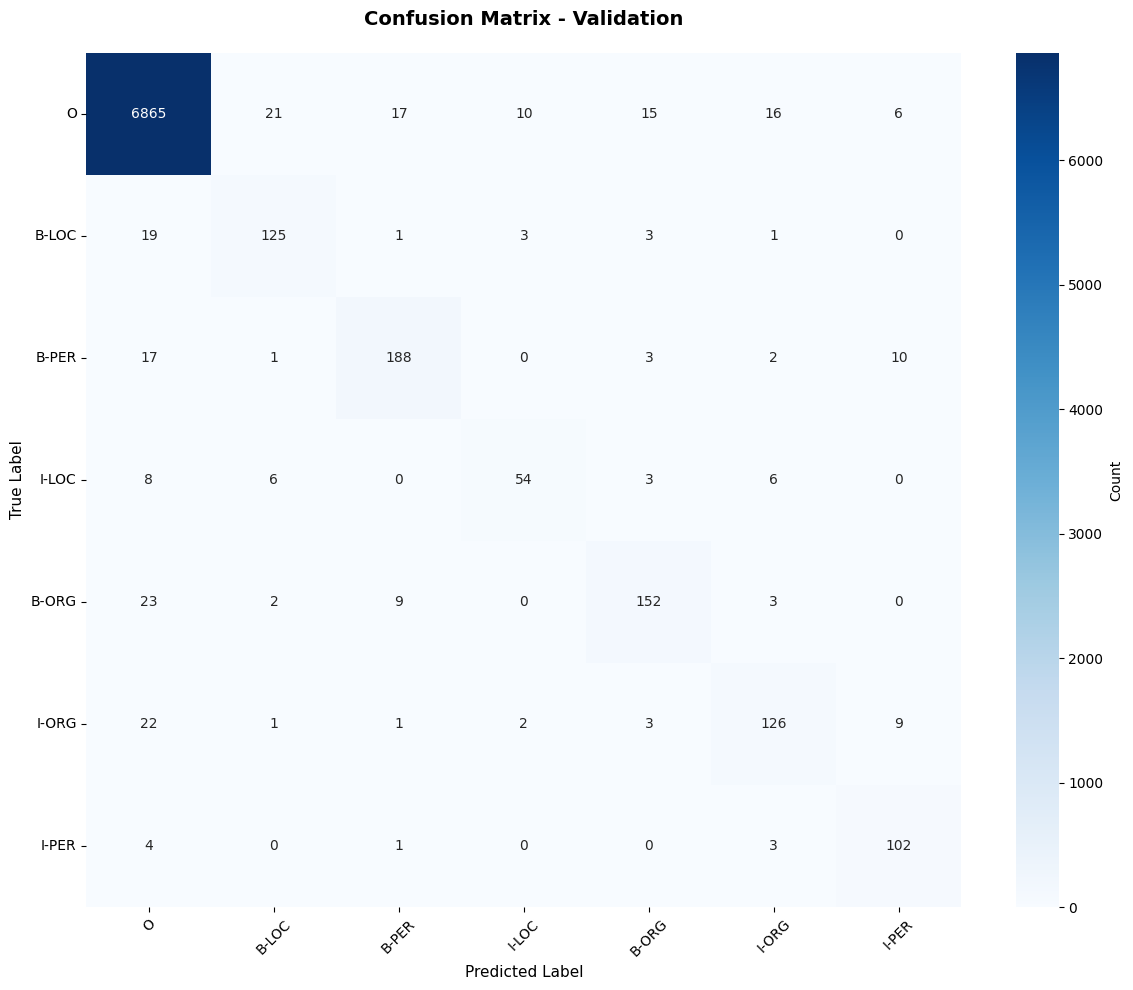

In [ ]:
print("\n" + "="*60)
print("DEV SET VALIDATION")
print("="*60)

y_dev_pred = crf.predict(X_dev)
all_labels = list(crf.classes_)
entity_labels = [l for l in all_labels if l != 'O']

print("\nClassification Report (Entity Labels):")
print(flat_classification_report(y_dev, y_dev_pred, labels=entity_labels, digits=4))

cm_dev = confusion_matrix(flatten(y_dev), flatten(y_dev_pred), labels=all_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_dev, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Validation', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


TESTING

Classification Report (Entity Labels):
              precision    recall  f1-score   support

       B-LOC     0.8136    0.9320    0.8688       103
       B-PER     0.9000    0.7689    0.8293       515
       I-LOC     0.8046    0.8537    0.8284        82
       B-ORG     0.8740    0.8479    0.8608       401
       I-ORG     0.7803    0.8340    0.8063       247
       I-PER     0.9022    0.9144    0.9083       222

   micro avg     0.8608    0.8350    0.8477      1570
   macro avg     0.8458    0.8585    0.8503      1570
weighted avg     0.8642    0.8350    0.8474      1570



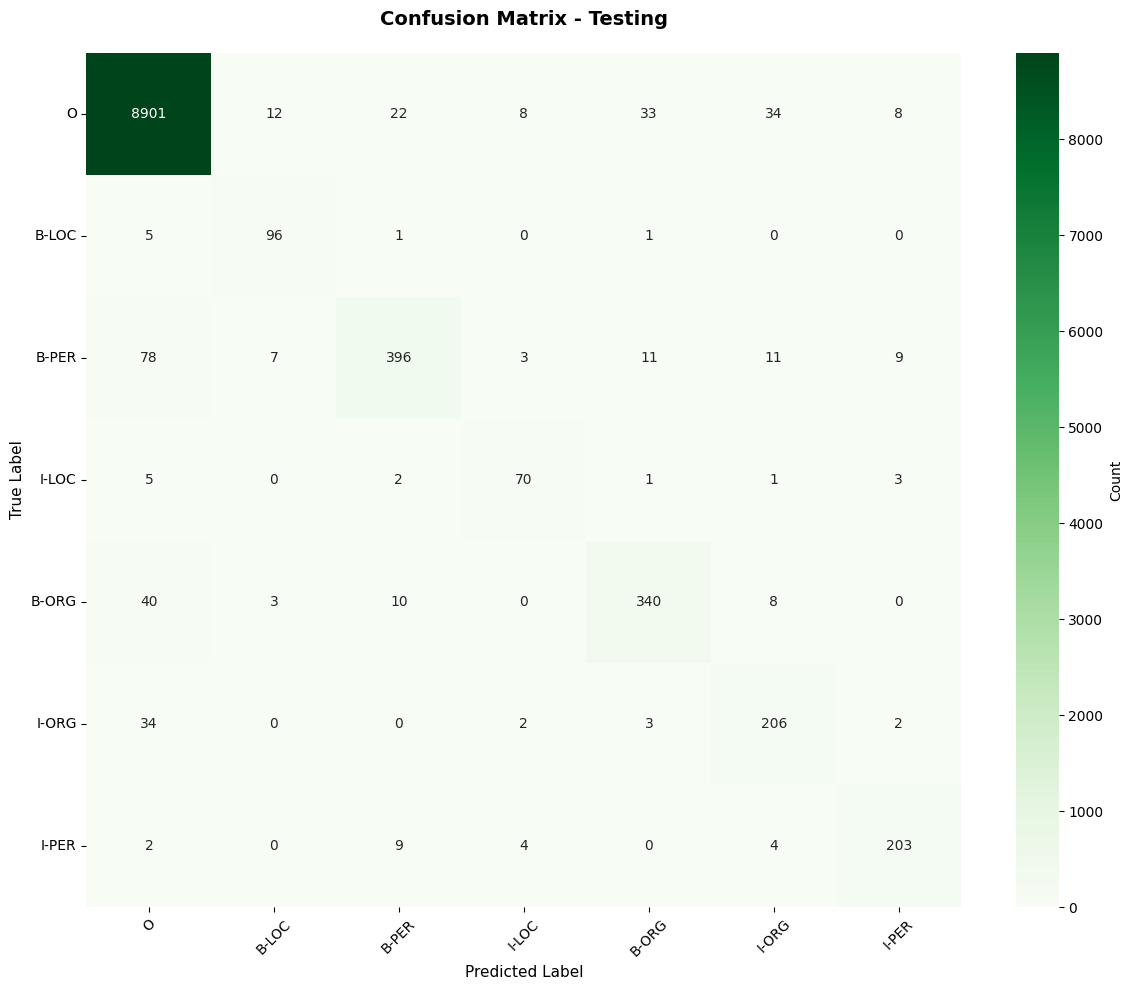

In [ ]:
print("\n" + "="*60)
print("TESTING")
print("="*60)

y_test_pred = crf.predict(X_test)

print("\nClassification Report (Entity Labels):")
print(flat_classification_report(y_test, y_test_pred, labels=entity_labels, digits=4))

cm_test = confusion_matrix(flatten(y_test), flatten(y_test_pred), labels=all_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=all_labels, yticklabels=all_labels, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Testing', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("PER-ENTITY ANALYSIS (PER, ORG, LOC)")
entity_types = ['PER', 'ORG', 'LOC']
specific_entities = [l for l in all_labels if any(l.startswith(f'B-{e}') or l.startswith(f'I-{e}') for e in entity_types)]

if specific_entities:
    print("\nDetailed Performance by Entity Type:")
    print(flat_classification_report(y_test, y_test_pred, labels=specific_entities, digits=4))
else:
    print("No entity labels found matching PER, ORG, or LOC")

print("\n" + "="*60)
print("FILES SAVED")
print("="*60)
print("Models:")
print("  - fasttext_model.bin")
print("  - crf_model.pkl")

PER-ENTITY ANALYSIS (PER, ORG, LOC)

Detailed Performance by Entity Type:
              precision    recall  f1-score   support

       B-LOC     0.8136    0.9320    0.8688       103
       B-PER     0.9000    0.7689    0.8293       515
       I-LOC     0.8046    0.8537    0.8284        82
       B-ORG     0.8740    0.8479    0.8608       401
       I-ORG     0.7803    0.8340    0.8063       247
       I-PER     0.9022    0.9144    0.9083       222

   micro avg     0.8608    0.8350    0.8477      1570
   macro avg     0.8458    0.8585    0.8503      1570
weighted avg     0.8642    0.8350    0.8474      1570


FILES SAVED
Models:
  - fasttext_model.bin
  - crf_model.pkl


In [ ]:
def predict_entities(text, nlp, fasttext_model, crf_model):

    doc = nlp(text)
    sentence = []
    for sent in doc.sentences:
        for word in sent.words:
            sentence.append((word.text, word.upos, 'O'))
    features = sent2features(sentence, fasttext_model)
    predictions = crf_model.predict([features])[0]
    results = []
    for i, (token, pos, _) in enumerate(sentence):
        results.append({
            'token': token,
            'pos': pos,
            'entity': predictions[i]
        })

    return results

nlp = stanza.Pipeline(lang='id', processors='tokenize,pos', verbose=False)

test_text = """
Presiden Joko Widodo bersama Menteri Keuangan Sri Mulyani menghadiri rapat terbatas di Istana Negara, Jakarta, pada hari Senin.
Dalam rapat tersebut, Bank Indonesia melaporkan perkembangan inflasi nasional dan kondisi nilai tukar rupiah.
Selain itu, Gubernur Jawa Barat Ridwan Kamil melaporkan progres pembangunan Kereta Cepat Jakarta–Bandung yang bekerja sama dengan PT KCIC.
Rapat juga membahas koordinasi antara Kementerian Kesehatan dan pemerintah daerah di Surabaya terkait peningkatan layanan kesehatan masyarakat.
"""
predictions = predict_entities(test_text, nlp, fasttext_model, crf)

print("\n" + "="*60)
print("PREDICTION TEST")
print("="*60)
print(f"\nInput: {test_text}\n")
print(f"{'Token':<20} {'POS':<10} {'Entity':<10}")
print("-" * 40)
for pred in predictions:
    print(f"{pred['token']:<20} {pred['pos']:<10} {pred['entity']:<10}")


PREDICTION TEST

Input: 
Presiden Joko Widodo bersama Menteri Keuangan Sri Mulyani menghadiri rapat terbatas di Istana Negara, Jakarta, pada hari Senin.
Dalam rapat tersebut, Bank Indonesia melaporkan perkembangan inflasi nasional dan kondisi nilai tukar rupiah.
Selain itu, Gubernur Jawa Barat Ridwan Kamil melaporkan progres pembangunan Kereta Cepat Jakarta–Bandung yang bekerja sama dengan PT KCIC.
Rapat juga membahas koordinasi antara Kementerian Kesehatan dan pemerintah daerah di Surabaya terkait peningkatan layanan kesehatan masyarakat.


Token                POS        Entity    
----------------------------------------
Presiden             PROPN      O         
Joko                 PROPN      B-PER     
Widodo               PROPN      I-PER     
bersama              ADP        O         
Menteri              PROPN      O         
Keuangan             PROPN      O         
Sri                  PROPN      B-PER     
Mulyani              PROPN      I-PER     
menghadiri           VE